## Navigation 2D in track environment changing obstacle distribution randomly 

In [ ]:
import torch

import time

# import gymnasium

import tqdm
import sys, os
sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))

# add for visualization
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

from src.controller.mppi import MPPI
from src.envs.track_env.navigation_2d import Navigation2DTrackEnv

def convert_to_bytes(image):
    _, buffer = cv2.imencode('.jpg', image)
    return buffer.tobytes()

def main(save_mode: bool = False):
    env = Navigation2DTrackEnv()
    video_widget = widgets.Image(format='jpeg')
    display(video_widget)
    # solver
    solver = MPPI(
        horizon=20,
        num_samples=3000,
        dim_state=6,
        dim_control=2,
        dynamics=env.dynamics,
        cost_func=env.cost_function,
        u_min=env.u_min,
        u_max=env.u_max,
        sigmas=torch.tensor([0.7, 0.7]),
        lambda_=1.0,
        auto_lambda=False,
        exploration=0.5,
    )

    state = env.reset()
    env.regenerate_obstacles_safe()
    max_steps = 500
    total_time = 0.0
    step_count = 0
    obstacle_interval = 15


    # Simulation start
    for i in range(max_steps):
        start = time.time()
        if i % obstacle_interval == 0 and i != 0:
            env.regenerate_obstacles_safe()
        action_seq, state_seq = solver.forward(state=state)
        end = time.time()
        total_time += end - start
        step_count += 1

        current_state = state.detach().clone()
        current_state_batch = current_state.unsqueeze(0).unsqueeze(0)
        state, is_goal_reached = env.step(action_seq[0, :])

        # collision check for predicted trajectory
        is_collisions = env.collision_check(state=state_seq)
        
        # collision check for current robot
        is_robot_collision = env.collision_check(state=current_state_batch)

        top_samples, top_weights = solver.get_top_samples(num_samples=300)
        u_ref = solver.get_spectral_expansion()

        if save_mode:
            env.render(
                action=action_seq[0, :],
                predicted_trajectory=state_seq,
                is_collisions=is_collisions,
                top_samples=(top_samples, top_weights),
                u_ref = u_ref,
                is_robot_collision = is_robot_collision,
                mode="rgb_array",
            )
            # progress bar
            if i == 0:
                pbar = tqdm.tqdm(total=max_steps, desc="recording video")
            pbar.update(1)

        else:
            env.render(
                action=action_seq[0, :],
                predicted_trajectory=state_seq,
                is_collisions=is_collisions,
                is_robot_collision = is_robot_collision,
                u_ref = u_ref,
                top_samples=(top_samples, top_weights),
                mode="human",
            )
        
        # add for visualization
        frame = env.get_current_frame()
        frame_rgb = frame[:, :, :3]  # RGBA → RGB
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)  # OpenCV용
        video_widget.value = convert_to_bytes(frame_bgr)
        clear_output(wait=True)
        display(video_widget)
        time.sleep(0.001)  # 100Hz

        if is_goal_reached:
            print("Goal Reached!")
            break

    average_time = total_time / step_count
    print("average solve time: {:.3f} ms".format(average_time * 1000))
    env.close()  # close window and save video if save_mode is True


if __name__ == "__main__":
    main(save_mode = False)


## Navigation 2D for dynamical environment

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

torch.Size([40, 12])


KeyboardInterrupt: 

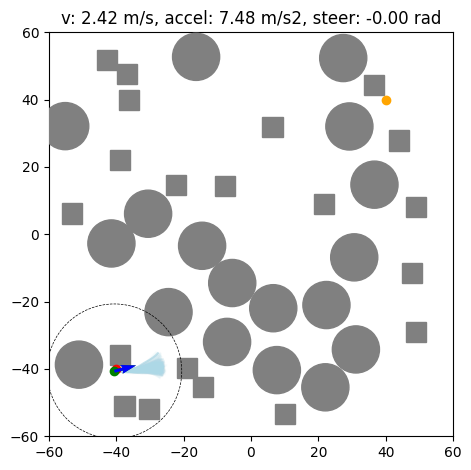

In [1]:
import torch

import time

# import gymnasium

import tqdm
import sys, os
sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))

# add for visualization
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

from src.controller.mppi import MPPI
from src.envs.static_env.navigation_2d import Navigation2DEnv



def convert_to_bytes(image):
    """Convert an OpenCV image (BGR) to JPEG bytes for widget display."""
    _, buffer = cv2.imencode('.jpg', image)
    return buffer.tobytes()


def main(save_mode: bool = False):
    # Initialize environment
    env = Navigation2DEnv()

    # Create a widget to display video frames in Jupyter
    video_widget = widgets.Image(format='jpeg')
    display(video_widget)

    # Initialize MPPI solver
    solver = MPPI(
        horizon=20,
        num_samples=3000,
        dim_state=6,
        dim_control=2,
        dynamics=env.dynamics,
        cost_func=env.cost_function,
        u_min=env.u_min,
        u_max=env.u_max,
        sigmas=torch.tensor([0.7, 0.7]),
        lambda_=1.0,
        auto_lambda=False,
        exploration=0.5,
    )

    # Reset environment to initial state
    state = env.reset()

    if not torch.is_tensor(state):
        state = torch.tensor(state, dtype=torch.float32)

    state = state.squeeze()

    max_steps = 500
    total_time = 0.0
    step_count = 0

    # Main simulation loop
    for i in range(max_steps):
        start = time.time()

        # Compute optimal action sequence and predicted trajectory
        action_seq, state_seq = solver.forward(state=state)

        end = time.time()
        total_time += end - start
        step_count += 1

        # Apply first action from the sequence
        state, is_goal_reached = env.step(action_seq[0, :])

        # Check collision for predicted trajectory
        is_collisions = env.collision_check(state=state_seq)

        # Get top sampled trajectories (for visualization/debugging)
        top_samples, top_weights = solver.get_top_samples(num_samples=300)

        # Render environment to RGB array (no GUI window)
        env.render(
            action=action_seq[0, :],
            predicted_trajectory=state_seq,
            is_collisions=is_collisions,
            top_samples=(top_samples, top_weights),
            mode="rgb_array",
        )

        # Get current rendered frame from environment
        frame = env.get_current_frame()

        # Convert RGBA → RGB (drop alpha channel)
        frame_rgb = frame[:, :, :3]

        # Convert RGB → BGR (required by OpenCV)
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

        # Update widget with new frame
        video_widget.value = convert_to_bytes(frame_bgr)

        # Refresh display (avoid stacking outputs)
        clear_output(wait=True)
        display(video_widget)

        # Small delay to control playback speed (~100Hz)
        time.sleep(0.001)

        # Stop if goal is reached
        if is_goal_reached:
            print("Goal Reached!")
            break

    # Compute average solver time
    average_time = total_time / step_count
    print("average solve time: {:.3f} ms".format(average_time * 1000))

    # Close environment (important for cleanup)
    env.close()


# Run in Jupyter
main(save_mode=False)

## Cfg + Wrapper style ver. (Static obstacle map)

In [ ]:
import torch
import time
import sys, os

sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))

# visualization
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

# ===== wrapper-based structure =====
from source.envs.navigation_wrapper import NavigationWrapper
from source.controller.mppi import MPPI
from source.tasks.navigation.navigation_cfg import MPPINavigationCfg


def convert_to_bytes(image):
    """Convert OpenCV BGR image to JPEG bytes for widget display."""
    _, buffer = cv2.imencode('.jpg', image)
    return buffer.tobytes()


def main(cfg, save_mode: bool = False):

    # =========================================================
    # 1. Wrapper (env + cost + collision 통합)
    # =========================================================
    wrapper = NavigationWrapper(cfg)
    

    # =========================================================
    # 2. MPPI controller
    # =========================================================
    solver = MPPI(
        horizon=cfg.mppi.horizon,
        num_samples=cfg.mppi.num_samples,
        dim_state=6,
        dim_control=2,
        dynamics=wrapper.dynamics,        # 🔥 wrapper 사용
        cost_func=wrapper.mppi_cost,   # 🔥 wrapper 사용
        u_min=wrapper.u_min,
        u_max=wrapper.u_max,
        sigmas=torch.tensor(cfg.mppi.sigmas),
        lambda_=cfg.mppi.lambda_,
        auto_lambda=False,
        exploration=cfg.mppi.exploration,
    )

    # =========================================================
    # 3. Visualization widget
    # =========================================================
    video_widget = widgets.Image(format='jpeg')
    display(video_widget)

    # =========================================================
    # 4. Reset
    # =========================================================
    state = wrapper.reset()

    max_steps = cfg.sim.max_steps
    total_time = 0.0
    step_count = 0

    # =========================================================
    # 5. Main loop
    # =========================================================
    for i in range(max_steps):

        start_time = time.time()

        # MPPI solve
        action_seq, state_seq = solver.forward(state=state)

        total_time += (time.time() - start_time)
        step_count += 1

        # apply action
        state, _, done, _ = wrapper.step(action_seq[0])

        # collision (visualization only)
        traj_collision = wrapper.collision_checker.check_trajectory(state_seq)

        # top samples
        top_samples, top_weights = solver.get_top_samples(num_samples=300)

        # =====================================================
        # Rendering
        # =====================================================
        frame = wrapper.render(
                state=state,
                action=action_seq[0],
                predicted_trajectory=state_seq,
                collisions=traj_collision,
                top_samples=(top_samples, top_weights),
            )

        frame_bgr = cv2.cvtColor(frame[:, :, :3], cv2.COLOR_RGB2BGR)

        video_widget.value = convert_to_bytes(frame_bgr)

        clear_output(wait=True)
        display(video_widget)

        time.sleep(0.001)

        if done:
            print("Goal Reached!")
            break

    # =========================================================
    # 6. Performance
    # =========================================================
    avg_time = total_time / step_count
    print(f"Average solve time: {avg_time * 1000:.3f} ms")


# Run in Jupyter
if __name__ == "__main__":
    main(cfg=MPPINavigationCfg(), save_mode=False)